In [1]:
pip install pandas numpy matplotlib shap scikit-learn

  Using cached shap-0.46.0-cp311-cp311-win_amd64.whl (456 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import shap
from IPython.display import display

c:\Users\aleja\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carga de datos

In [3]:
x_test_smote_url = 'https://www.dropbox.com/scl/fi/s6n7on7xlek9rlryrwvly/x_test_smote.csv?rlkey=yvv6qycatwob654ac46u4hw5j&st=8i0eje2i&dl=1'
x_train_smote_url = 'https://www.dropbox.com/scl/fi/pxcfuv0lbfaqxg1id31i4/x_train_smote.csv?rlkey=iassne8jnptwnqmyc6iyvdfk9&st=jryk50k4&dl=1'
genus_test_labels_smote_url =  'https://www.dropbox.com/scl/fi/l72oav7pii13j70rvzhmj/genus_test_labels_smote.csv?rlkey=2ubjiz2pa3l6gvwlcv1nxmdbv&st=hnb4kk23&dl=1'
genus_train_labels_smote_url = 'https://www.dropbox.com/scl/fi/mam4h1ozy5aii9jax06nc/genus_train_labels_smote.csv?rlkey=xq5mdiqahnwmoy84341z4nk3v&st=p0gdmy7u&dl=1'
genus_species_test_labels_smote_url = 'https://www.dropbox.com/scl/fi/tgvkp04eo2mza9wrs8ihf/genus_species_test_labels_smote.csv?rlkey=mi2l1x7ptkchuxcms7hj73rd5&st=y5j86fgk&dl=1'
genus_species_train_labels_smote_url = 'https://www.dropbox.com/scl/fi/sxsc0otdb2ezsglpy23bl/genus_species_train_labels_smote.csv?rlkey=z6wylnd533son8qbtctkh9j9u&st=4m17zp7e&dl=1'

x_test_smote = pd.read_csv(x_test_smote_url)
x_train_smote = pd.read_csv(x_train_smote_url)
genus_test_labels_smote = pd.read_csv(genus_test_labels_smote_url)
genus_train_labels_smote = pd.read_csv(genus_train_labels_smote_url)
genus_species_test_labels_smote = pd.read_csv(genus_species_test_labels_smote_url)
genus_species_train_labels_smote = pd.read_csv(genus_species_train_labels_smote_url)

print("x_test_smote shape:", x_test_smote.shape)
print("x_train_smote shape:", x_train_smote.shape)
print("genus_test_labels_smote shape:", genus_test_labels_smote.shape)
print("genus_train_labels_smote shape:", genus_train_labels_smote.shape)
print("genus_species_test_labels_smote shape:", genus_species_test_labels_smote.shape)
print("genus_species_train_labels_smote shape:", genus_species_train_labels_smote.shape)

x_test_smote shape: (1476, 3000)
x_train_smote shape: (22440, 3000)
genus_test_labels_smote shape: (1476, 1)
genus_train_labels_smote shape: (6452, 1)
genus_species_test_labels_smote shape: (1476, 1)
genus_species_train_labels_smote shape: (22440, 1)


# n_steps = 6

In [4]:
X_train = x_train_smote.values
X_test = x_test_smote.values
Y_train = genus_species_train_labels_smote.values.ravel()
Y_test = genus_species_test_labels_smote.values.ravel()

## KNN

In [ ]:
knn_best_genus_species = KNeighborsClassifier(n_neighbors=7, weights='uniform', metric='euclidean', algorithm='auto')

In [ ]:
knn_best_genus_species.fit(X_train, Y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7)

### SHAP

In [ ]:
# Seleccionamos un subconjunto de fondo (por ejemplo, 100 muestras aleatorias) del conjunto de entrenamiento
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# Creamos el objeto explainer utilizando la función predict_proba del clasificador KNN
explainer = shap.KernelExplainer(knn_best_genus_species.predict_proba, background)

# Filtramos las instancias del conjunto de prueba con etiqueta 6
indices_label6 = np.where(Y_test == 6)[0]

#### SHAP Values global

In [ ]:
if len(indices_label6) > 0:
    # Extraemos todas las muestras de la clase 6
    X_test_label6 = X_test[indices_label6]
    
    # Calculamos los SHAP values para estas instancias.
    # En problemas multiclase, shap_values es una lista donde cada posición corresponde a una clase.
    shap_values = explainer.shap_values(X_test_label6)
    
    # Mostramos un summary plot global para la clase 6.
    # Se asume que shap_values[6] contiene los valores para la clase 6.
    shap.summary_plot(shap_values[6], X_test_label6, feature_names=None)
else:
    print("No se encontraron instancias en X_test con la etiqueta 6.")


#### SHAP Values local

In [ ]:
if len(indices_label6) > 0:
    # Seleccionamos, por ejemplo, las primeras 3 muestras de la clase 6 (o menos si hay menos)
    num_samples = min(3, len(indices_label6))
    X_samples = X_test[indices_label6[:num_samples]]
    
    # Calculamos los SHAP values para estas muestras.
    # shap_values_multi es una lista con una entrada por clase; nos interesa la correspondiente a la clase 6.
    shap_values_multi = explainer.shap_values(X_samples)
    
    # Inicializamos la visualización interactiva (útil en Jupyter Notebook)
    shap.initjs()
    
    # Para cada muestra, generamos un waterfall plot (similar a lo obtenido para Random Forest)
    for i in range(num_samples):
        sample = X_samples[i]  # Vector 1D con shape (n_features,)
        shap_value = shap_values_multi[6][i]  # SHAP values para la muestra i, para la clase 6
        
        # Creamos el objeto Explanation para el waterfall plot
        explanation = shap.Explanation(values=shap_value,
                                       base_values=explainer.expected_value[6],
                                       data=sample,
                                       feature_names=None)
        
        print(f"Waterfall plot para la muestra {i+1}:")
        shap.plots.waterfall(explanation)
else:
    print("No se encontraron instancias en X_test con la etiqueta 6.")

## Random Forest

In [5]:
random_forest_model = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', bootstrap=True, random_state=42)

In [6]:
random_forest_model.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

### SHAP

In [7]:
import shap

background = X_train
print("Dimensiones de background:", background.shape)

# Crea el explainer usando el background
explainer_rf = shap.TreeExplainer(random_forest_model, background)

print("expected_value:", explainer_rf.expected_value)

# Filtra las instancias de X_test que tienen la etiqueta 6 (Aspergillus Fumigatus)
indices_label6 = np.where(Y_test == 6)[0]
X_test_label6 = X_test[indices_label6]
print("Dimensiones de X_test_label6:", X_test_label6.shape)  # (n_samples_clase6, 3000)

# Calcula los SHAP values para X_test_label6.
shap_values_rf = explainer_rf.shap_values(X_test_label6, check_additivity=False)
print("Dimensiones de shap_values_rf:", shap_values_rf.shape)

shap_values_class6 = shap_values_rf[:, :, 6]
print("Dimensiones de shap_values_class6:", shap_values_class6.shape)


Dimensiones de background: (22440, 3000)
expected_value: [0.    0.009 0.01  0.01  0.01  0.02  0.02  0.039 0.    0.    0.021 0.01
 0.022 0.01  0.02  0.02  0.02  0.02  0.01  0.    0.01  0.02  0.03  0.019
 0.03  0.    0.01  0.    0.01  0.    0.01  0.02  0.01  0.04  0.04  0.02
 0.03  0.01  0.    0.03  0.    0.03  0.01  0.02  0.01  0.03  0.04  0.
 0.02  0.05  0.03  0.031 0.01  0.02  0.03  0.    0.01  0.03  0.    0.019]
Dimensiones de X_test_label6: (70, 3000)
Dimensiones de shap_values_rf: (70, 3000, 60)
Dimensiones de shap_values_class6: (70, 3000)


#### SHAP Values gobal

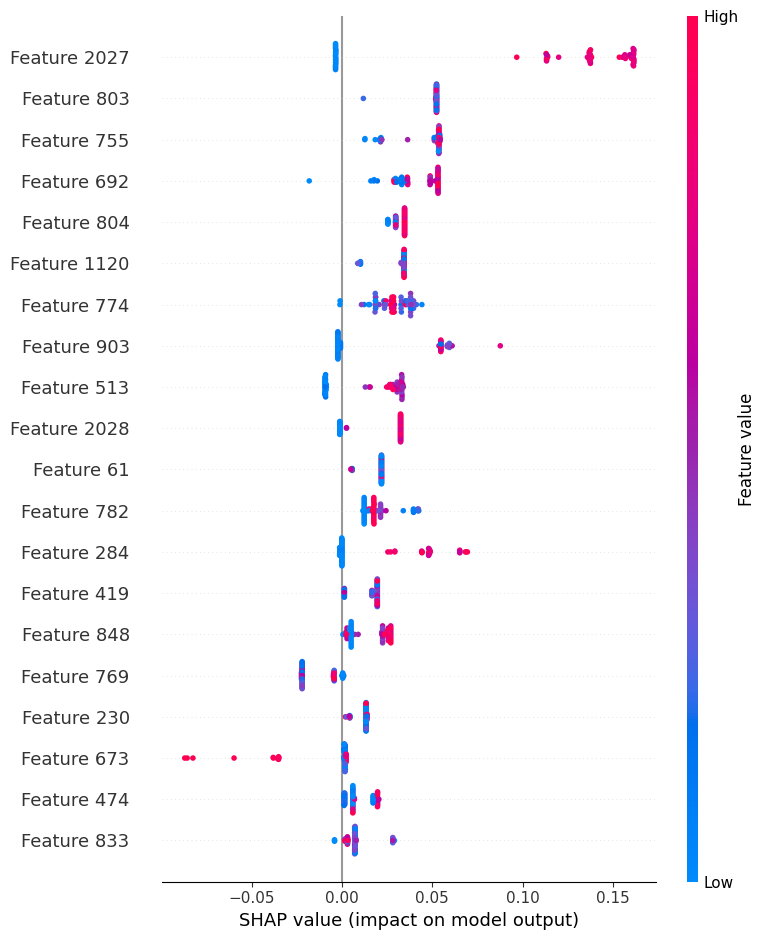

In [8]:
shap.summary_plot(shap_values_class6, X_test_label6, feature_names=None)

#### SHAP Values local

Usando 3 muestras para la explicación local.
Dimensiones de shap_values_selected: (3, 3000, 60)
Dimensiones de shap_values_class6: (3, 3000)


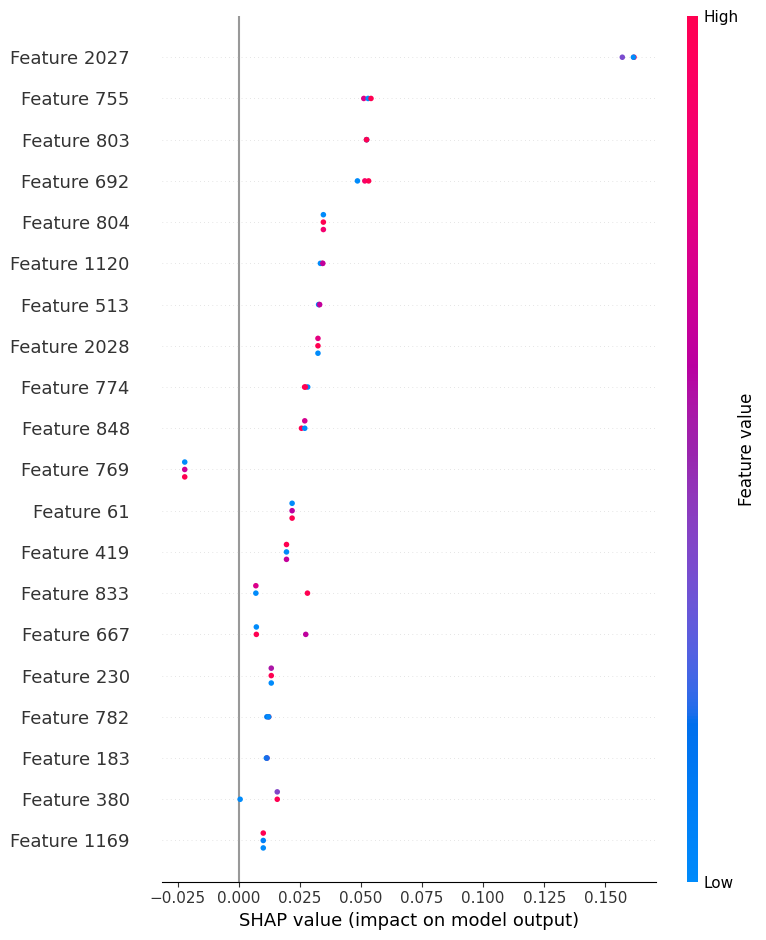


Waterfall plot para la muestra 1:


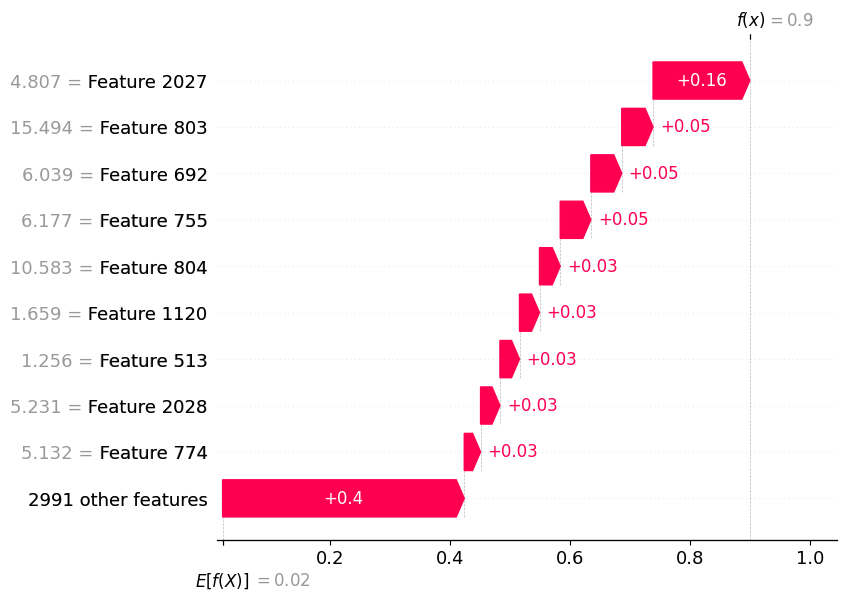


Waterfall plot para la muestra 2:


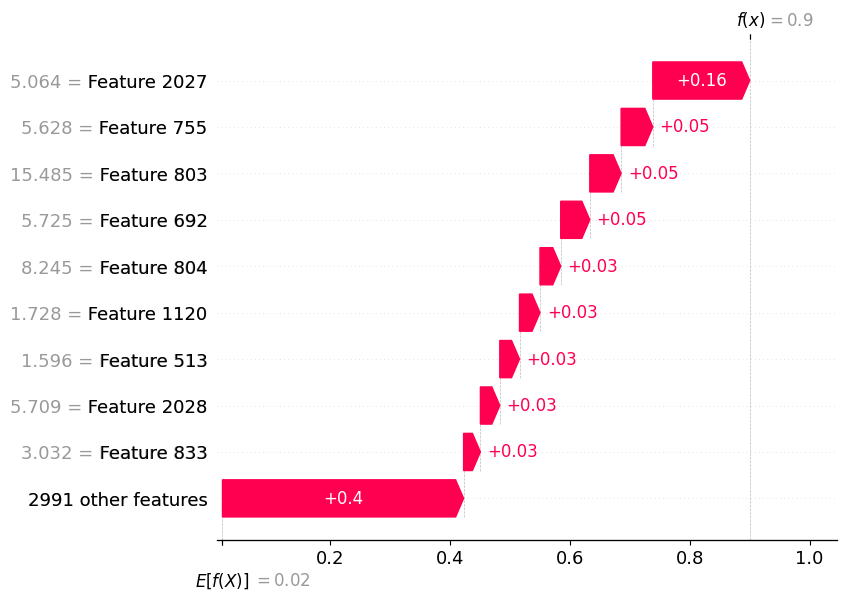


Waterfall plot para la muestra 3:


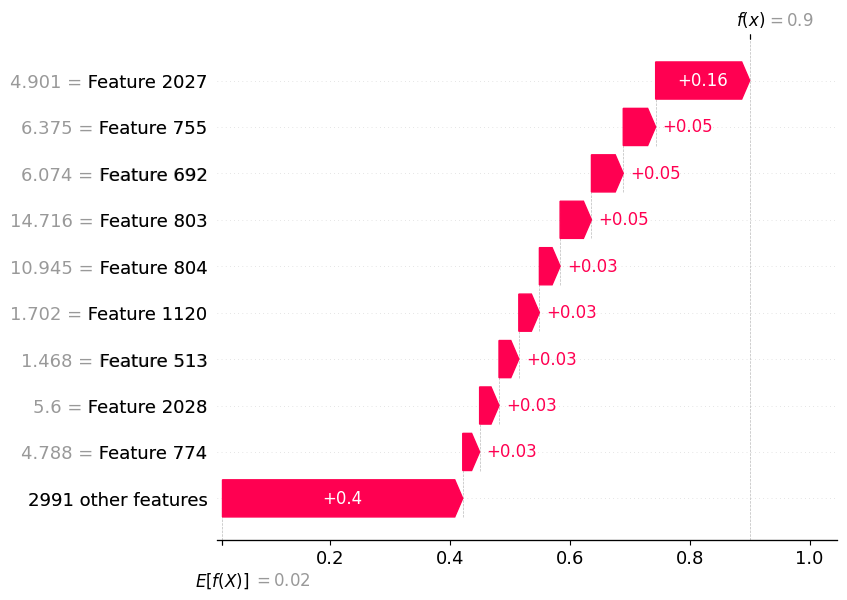

In [11]:
num_samples = min(3, X_test_label6.shape[0])
selected_samples = X_test_label6[:num_samples]
print(f"Usando {num_samples} muestras para la explicación local.")
shap_values_selected = explainer_rf.shap_values(selected_samples, check_additivity=False)
print("Dimensiones de shap_values_selected:", shap_values_selected.shape)
shap_values_class6 = shap_values_selected[:, :, 6]
print("Dimensiones de shap_values_class6:", shap_values_class6.shape)
shap.summary_plot(shap_values_class6, selected_samples, feature_names=None)

# --- Explicabilidad local (waterfall plot) para cada muestra individual ---
for i in range(num_samples):
    # Para la muestra i, extraer el vector de SHAP values para la clase 6
    shap_values_sample_class6 = shap_values_selected[i, :, 6]  # forma: (n_features,)
    # Construir el objeto Explanation (requiere SHAP >= 0.41)
    explanation = shap.Explanation(values=shap_values_sample_class6,
                                   base_values=explainer_rf.expected_value[6],
                                   data=selected_samples[i],
                                   feature_names=None)
    
    print(f"\nWaterfall plot para la muestra {i+1}:")
    shap.plots.waterfall(explanation)

# n_steps = 3